In [1]:
from pathlib import Path

import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

data = pd.read_excel('initial_vs_new_SMILES_models_.xlsx')

print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())

print("\nDataset labels:")
display(data["dataset"].value_counts(dropna=False))

display(data.head())

Shape: (67, 28)
Columns:
['Unnamed: 0', 'Initial_SMILES', 'New_SMILES', 'epox_cla', 'dataset', 'Sterimol_Beta_R1_L', 'Sterimol_Beta_R1_B1', 'Sterimol_Beta_R1_B5', 'Sterimol_Beta_R2_L', 'Sterimol_Beta_R2_B1', 'Sterimol_Beta_R2_B5', 'Sterimol_Alpha_R1_L', 'Sterimol_Alpha_R1_B1', 'Sterimol_Alpha_R1_B5', 'Alpha_Charge', 'Beta_Charge', 'Acceptor_Charge', 'Beta_R1_EN', 'Beta_R1_Charge_Head', 'Beta_R1_Charge_Sum3', 'Beta_R2_EN', 'Beta_R2_Charge_Head', 'Beta_R2_Charge_Sum3', 'Alpha_R1_EN', 'Alpha_R1_Charge_Head', 'Alpha_R1_Charge_Sum3', 'Diff_Charge_Beta_Alpha', 'Diff_Charge_Acceptor_Alpha']

Dataset labels:


dataset
train    56
test     11
Name: count, dtype: int64

,Unnamed: 0,Initial_SMILES,New_SMILES,epox_cla,dataset,Sterimol_Beta_R1_L,Sterimol_Beta_R1_B1,Sterimol_Beta_R1_B5,Sterimol_Beta_R2_L,Sterimol_Beta_R2_B1,...,Beta_R1_Charge_Head,Beta_R1_Charge_Sum3,Beta_R2_EN,Beta_R2_Charge_Head,Beta_R2_Charge_Sum3,Alpha_R1_EN,Alpha_R1_Charge_Head,Alpha_R1_Charge_Sum3,Diff_Charge_Beta_Alpha,Diff_Charge_Acceptor_Alpha
0,0,CC3=CC=C(C=C3)[C@@H]4O[C@H]4C(C5=CC=CC=C5)=O,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc(C)cc1,1,train,6.943624,1.7,6.934047,3.616927,1.7,...,-0.016162,0.045083,2.2,0.068867,-0.169602,2.20,0.072318,0.417996,-0.034241,0.042593
1,1,ClC3=CC=CC=C3[C@@H]4[C@@H](C(C5=CC=CC=C5)=O)O4,[C@H]1(C(=O)c2ccccc2)O[C@@H]1c1ccccc1Cl,1,test,5.848231,1.7,5.758544,3.616699,1.7,...,0.002499,0.066412,2.2,0.068922,-0.168056,2.20,0.072319,0.418054,-0.032864,0.042538
2,2,ClC3=CC=C([C@@H]4O[C@H]4C(C5=CC=CC=C5)=O)C=C3,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc(Cl)cc1,1,train,6.645189,1.7,7.011927,3.617434,1.7,...,-0.016078,0.046385,2.2,0.068867,-0.169601,2.20,0.072318,0.417996,-0.034240,0.042593
3,3,[H][C@]1(O[C@@]1([H])C1=CC=CC=C1)C(=O)C1=CC=CC=C1,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccccc1,1,train,5.743783,1.7,5.818045,3.616975,1.7,...,-0.016182,0.044799,2.2,0.068867,-0.169603,2.20,0.072318,0.417996,-0.034241,0.042593
4,4,O=C4C5=CC=CC=C5CC[C@]46O[C@H]6C7=CC=CC=C7,[C@]12(CCc3ccccc3C1=O)O[C@H]2c1ccccc1,1,train,5.878383,1.7,5.730263,3.629593,1.7,...,-0.015871,0.048331,2.2,0.069200,-0.162500,2.55,-0.009194,0.129144,-0.041663,0.035333


In [2]:
import pandas as pd

data = pd.read_excel(
    "initial_vs_new_SMILES_models_.xlsx"
).copy()

required_columns = [
    "dataset",
    "New_SMILES",
]

missing_columns = [
    column
    for column in required_columns
    if column not in data.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}\n"
    f"Available columns: {data.columns.tolist()}"
)

# Detect the index column exported from pandas to Excel.
possible_index_columns = [
    "index",
    "Index",
    "Unnamed: 0",
    "unnamed: 0",
    "Unnamed:0",
]

INDEX_COL = next(
    (
        column
        for column in possible_index_columns
        if column in data.columns
    ),
    None,
)

if INDEX_COL is None:
    raise ValueError(
        "Could not detect an Excel index column.\n"
        f"Available columns: {data.columns.tolist()}"
    )

print(f"Detected index column: {INDEX_COL}")

data["Original_Index"] = pd.to_numeric(
    data[INDEX_COL],
    errors="raise",
).astype(int)

data["dataset"] = (
    data["dataset"]
    .astype(str)
    .str.strip()
    .str.lower()
)

data = data.loc[
    data["dataset"].isin(["train", "test"])
].copy()

train_df = data.loc[
    data["dataset"] == "train"
].copy()

test_df = data.loc[
    data["dataset"] == "test"
].copy()

# Use the actual descriptor-table / Excel indices.
train_df["Structure_ID"] = (
    #"Train #"
    "#"
    + train_df["Original_Index"].astype(str)
)

test_df["Structure_ID"] = (
    #"Test #"
    "#"
    + test_df["Original_Index"].astype(str)
)

train_df["Dataset_label"] = "Training set"
test_df["Dataset_label"] = "Development comparison set"

structures_df = pd.concat(
    [train_df, test_df],
    axis=0,
    ignore_index=True,
)

# Optional: organize each group in ascending original-index order.
structures_df = structures_df.sort_values(
    ["dataset", "Original_Index"]
).reset_index(drop=True)

print("Training structures:", len(train_df))
print("Test structures:", len(test_df))
print("Total structures:", len(structures_df))

display(
    structures_df[
        [
            "Structure_ID",
            "Dataset_label",
            "Original_Index",
            "New_SMILES",
        ]
    ].head(15)
)

Detected index column: Unnamed: 0
Training structures: 56
Test structures: 11
Total structures: 67


,Structure_ID,Dataset_label,Original_Index,New_SMILES
0,#1,Development comparison set,1,[C@H]1(C(=O)c2ccccc2)O[C@@H]1c1ccccc1Cl
1,#11,Development comparison set,11,[C@H]12O[C@H]1CCCCC2=O
2,#21,Development comparison set,21,[C@@H]1(C(=O)c2cc3ccccc3s2)O[C@H]1c1ccccc1
3,#26,Development comparison set,26,[C@@H]1(C(=O)c2ccccc2)O[C@H]1/C=C/C
4,#31,Development comparison set,31,[C@@H]1(C(=O)c2cccn2C)O[C@H]1c1ccccc1
5,#32,Development comparison set,32,[C@@H]1(C(=O)c2cccc3ccccc23)O[C@H]1c1ccccc1
6,#34,Development comparison set,34,[C@@H]1(C(=O)c2ccccc2)O[C@H]1C(C)C
7,#44,Development comparison set,44,[C@@H]1(C(=O)c2ccccc2)O[C@H]1c1ccc[nH]1
8,#47,Development comparison set,47,[C@@H]1(C(=O)CCCCCC)O[C@H]1c1ccccc1
9,#51,Development comparison set,51,C12(O[C@@H]1c1ccccc1)C(=O)CCCC2=O


In [3]:
def draw_train_test_molgrid(
    df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=200,
    img_size=(310, 270),
):
    molecules = []
    legends = []

    for dataframe_index, row in df.head(max_mols).iterrows():
        combined_smiles = str(row[smiles_col])

        molecule = Chem.MolFromSmiles(combined_smiles)

        if molecule is None:
            print(
                f"SMILES conversion error: "
                f"{row[id_col]} (row {dataframe_index})"
            )
            continue

        molecules.append(molecule)

        legends.append(
            f"{row[id_col]}"#\n{row[dataset_label_col]}"
        )

    if not molecules:
        raise ValueError("No valid molecules were generated.")

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.035
    draw_options.bondLineWidth = 2.2

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

C:\Users\aleks\anaconda3\envs\cheminf_gpu\Lib\site-packages\rdkit\Chem\Draw\IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


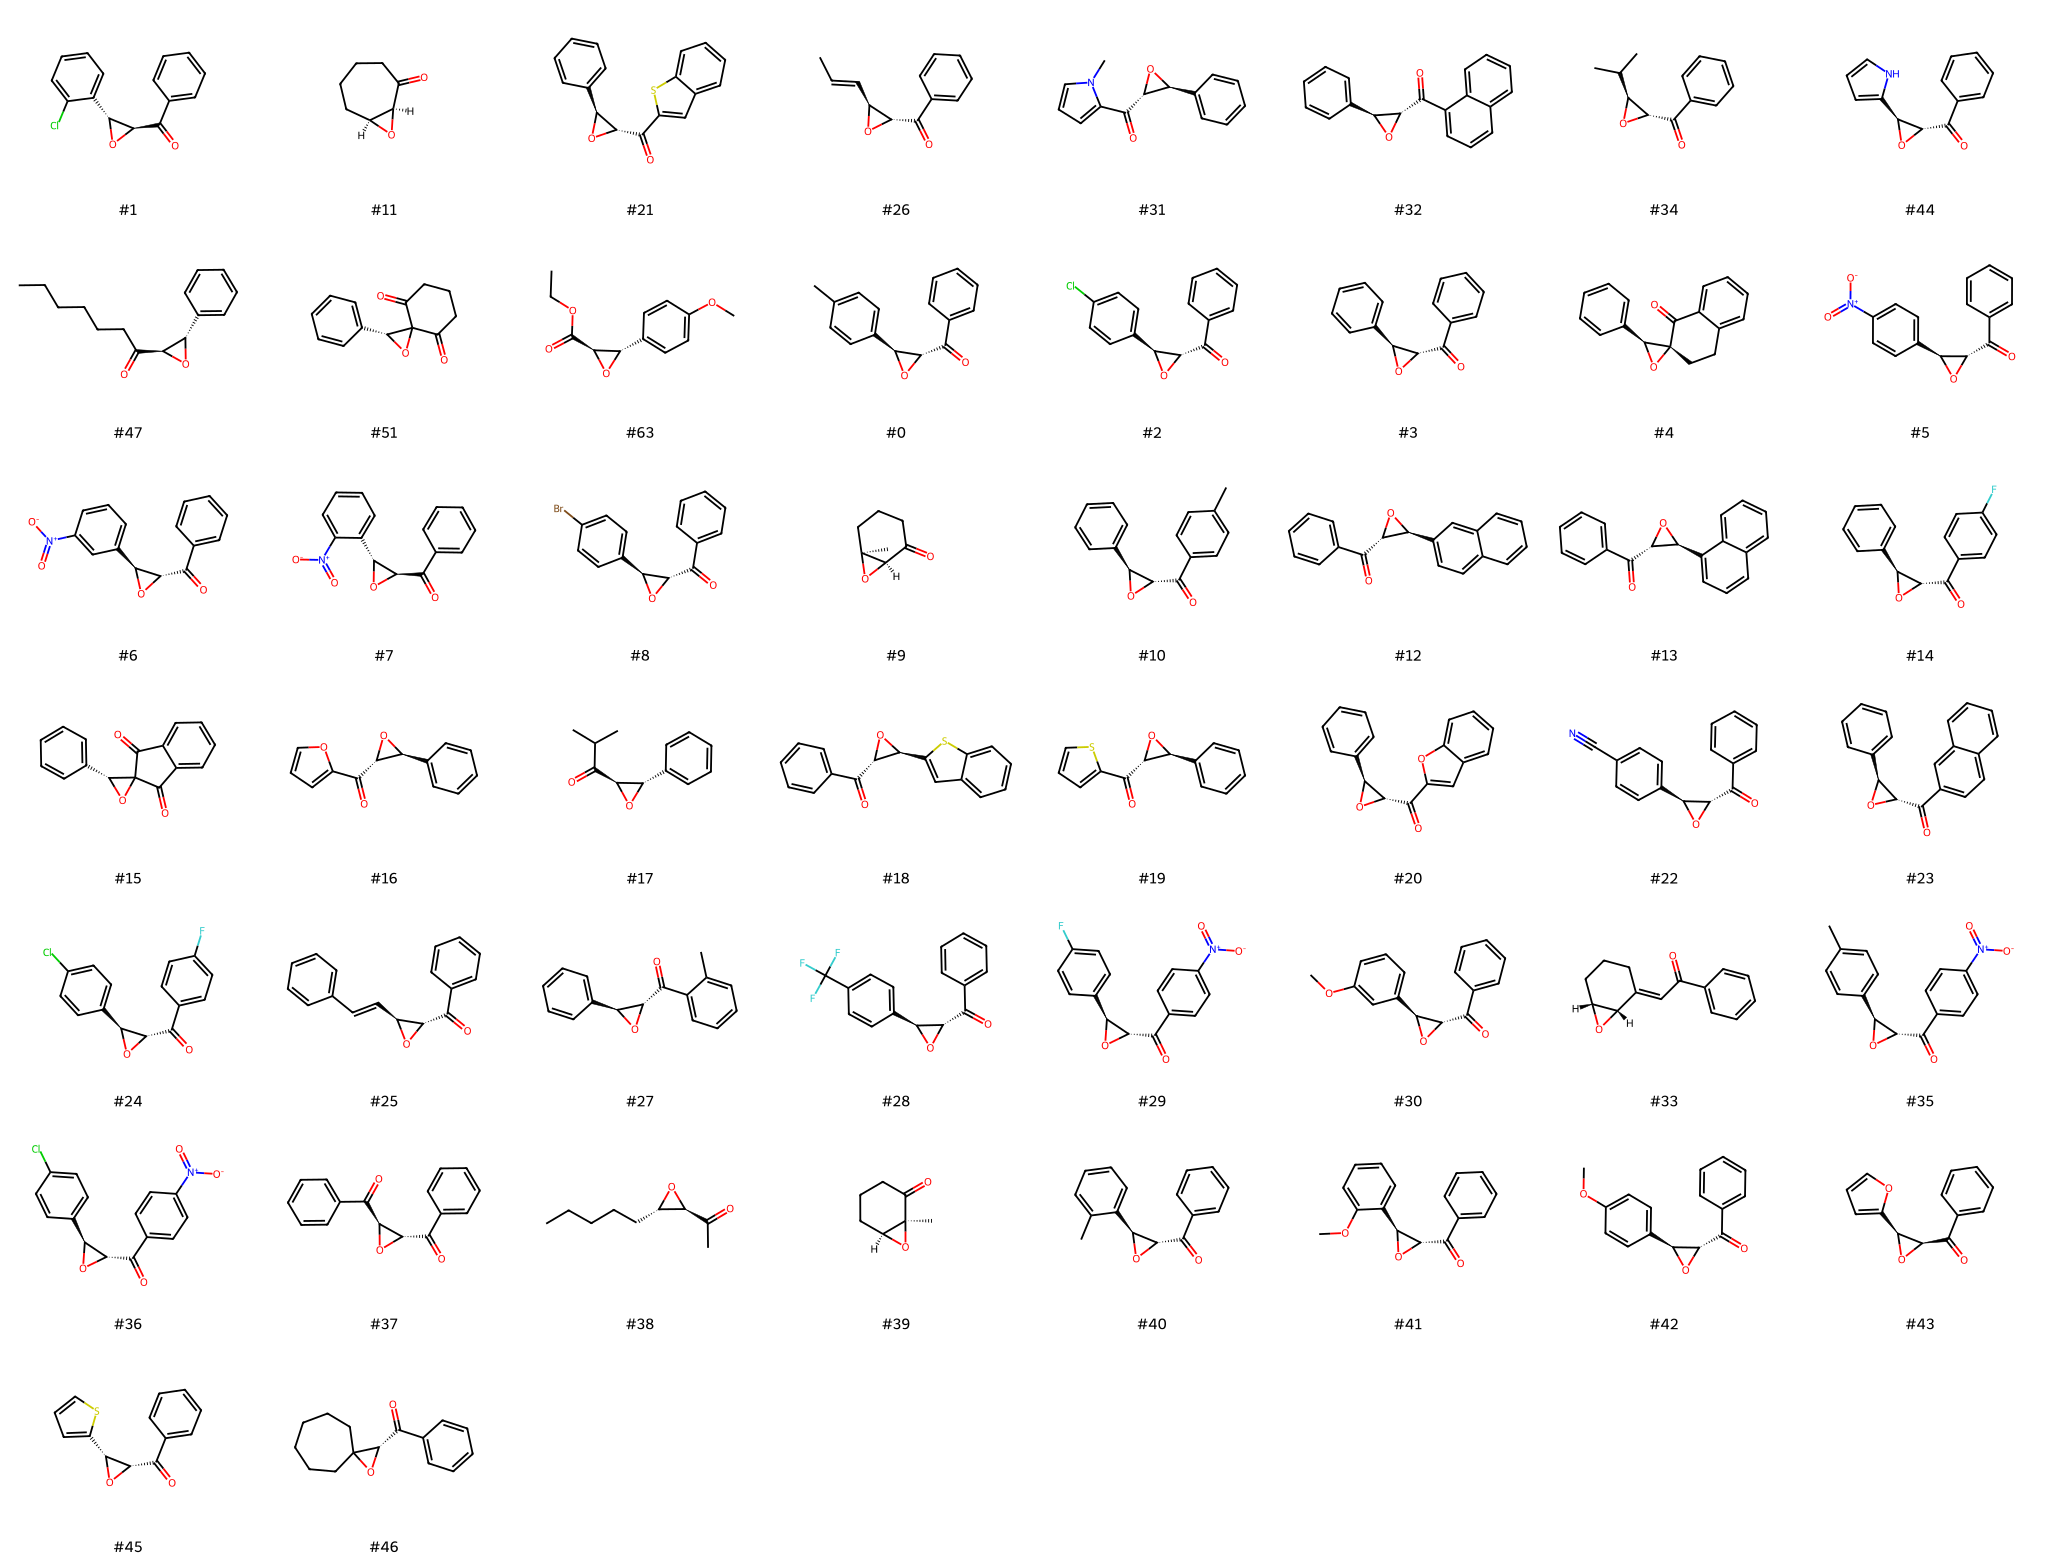

In [4]:
train_test_molgrid_svg = draw_train_test_molgrid(
    df=structures_df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=8,
    max_mols=100,#len(structures_df),
    img_size=(310, 270),
)

display(train_test_molgrid_svg)

In [5]:
def draw_train_test_molgrid(
    df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=8,
    max_mols=200,
    img_size=(310, 270),
):
    molecules = []
    legends = []

    for dataframe_index, row in df.head(max_mols).iterrows():
        molecule = Chem.MolFromSmiles(
            str(row[smiles_col])
        )

        if molecule is None:
            print(
                f"SMILES conversion error: "
                f"{row[id_col]} (row {dataframe_index})"
            )
            continue

        molecules.append(molecule)

        legends.append(
            f"{row[id_col]}\n"
            #f"{row[dataset_label_col]}"
        )

    if not molecules:
        raise ValueError("No valid molecules were generated.")

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.035
    draw_options.bondLineWidth = 2.2

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

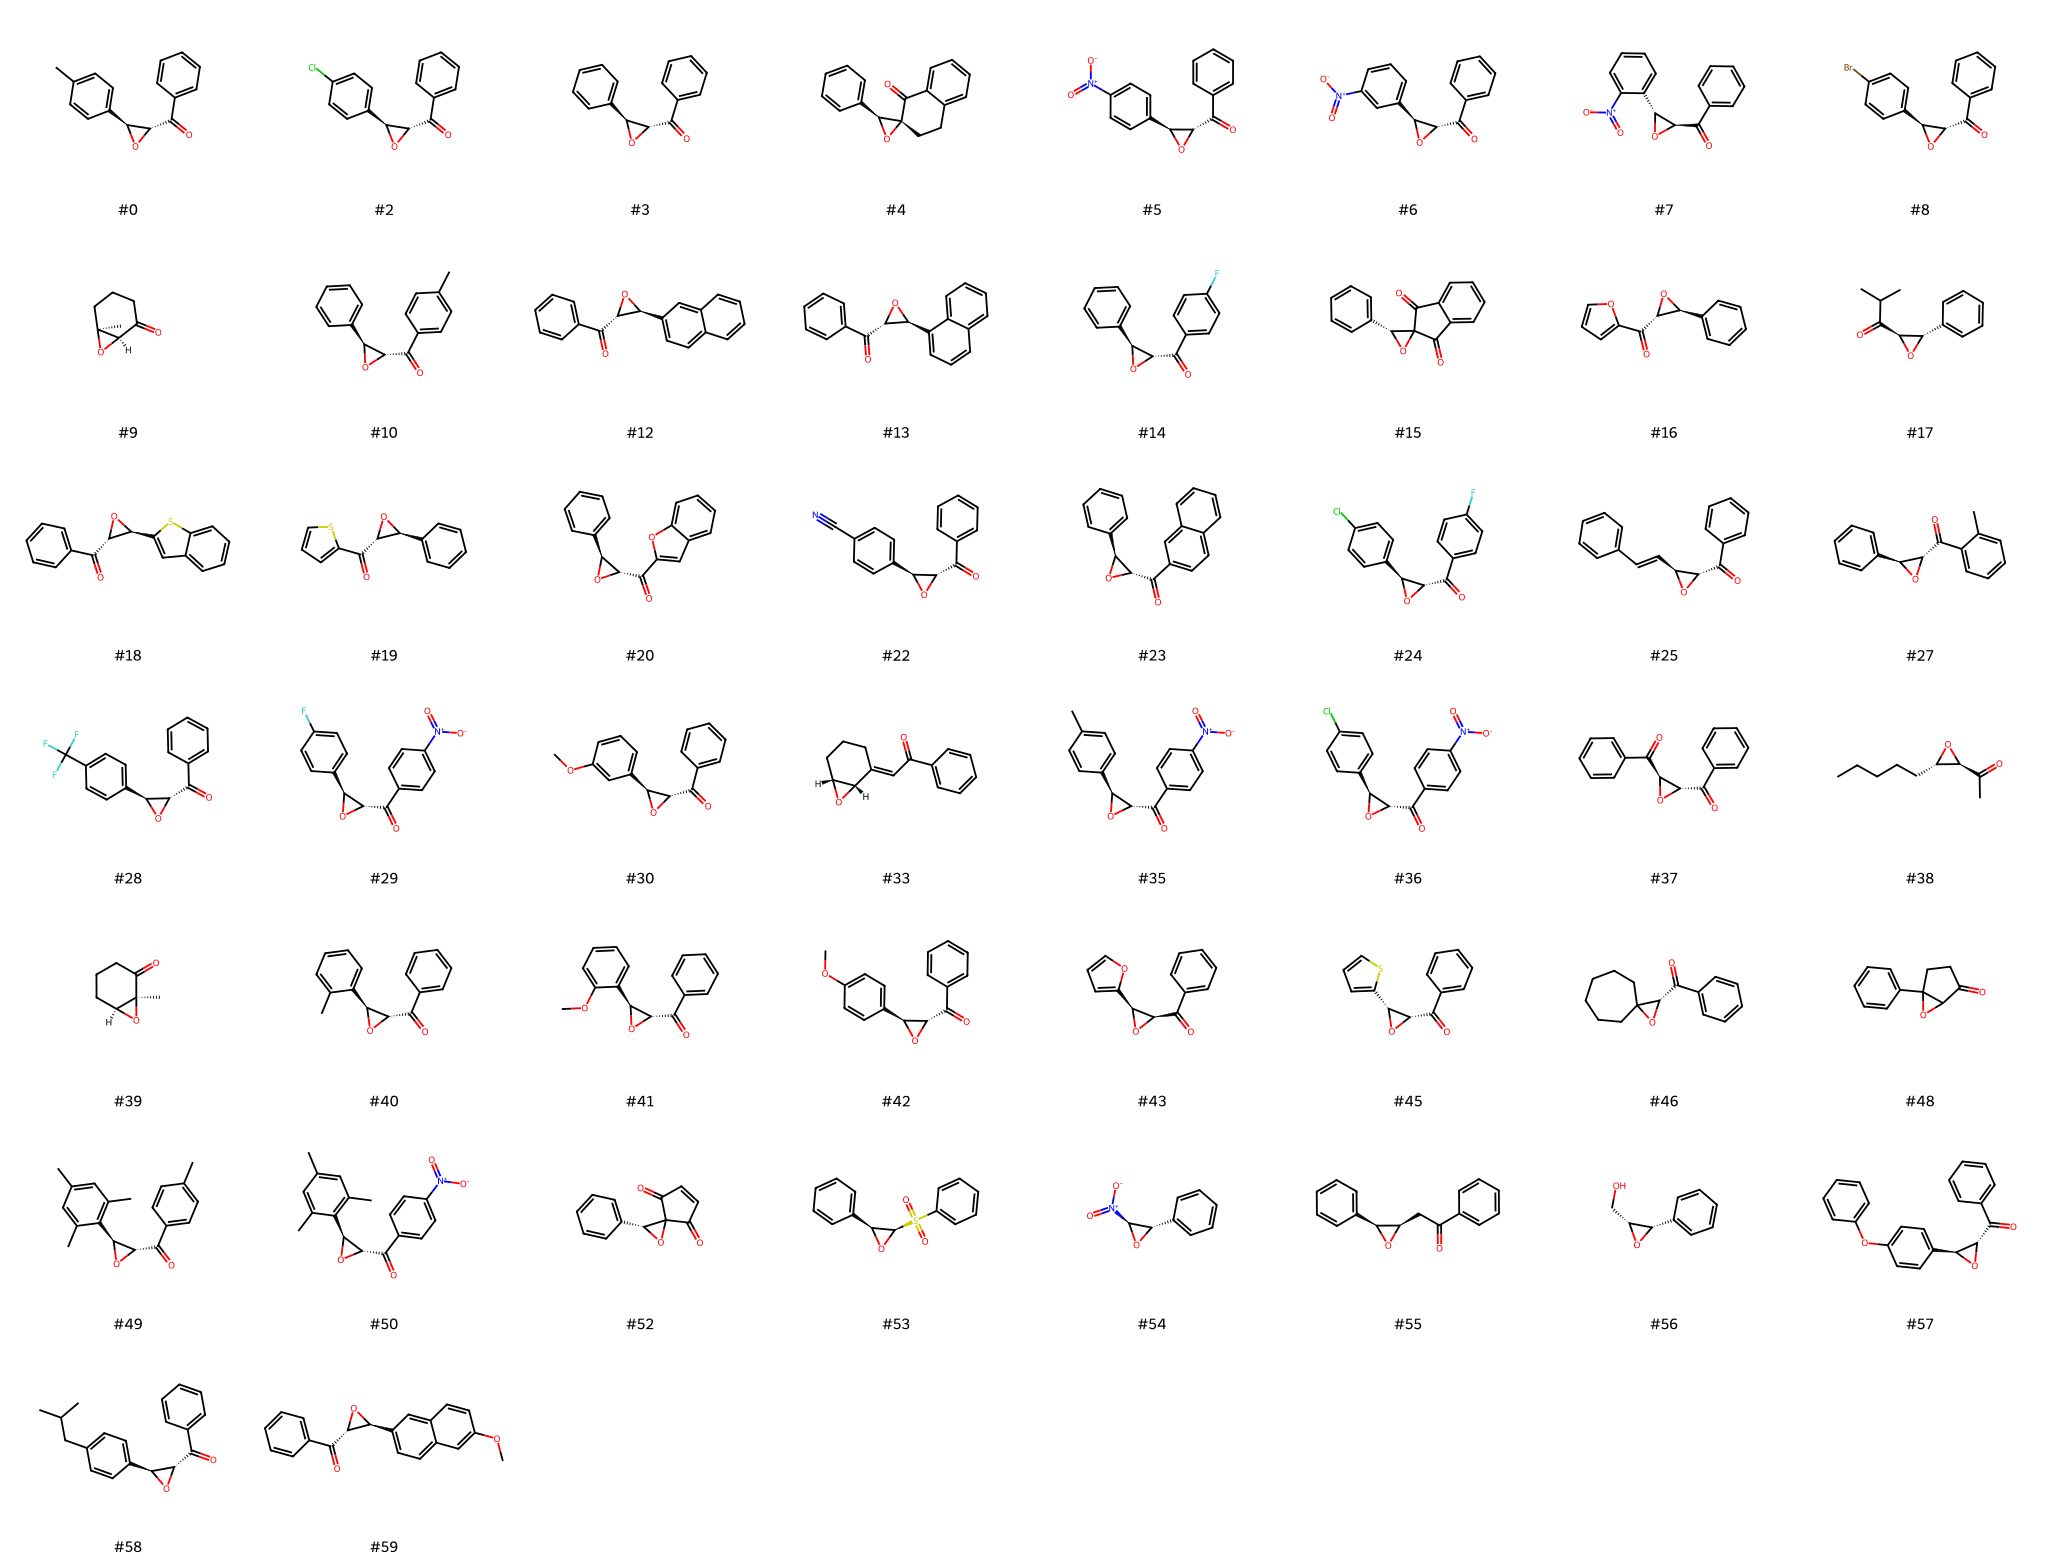

In [6]:
train_molgrid_svg = draw_train_test_molgrid(
    df=train_df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=8,
    max_mols=len(train_df),
    img_size=(310, 270),
)

display(train_molgrid_svg)

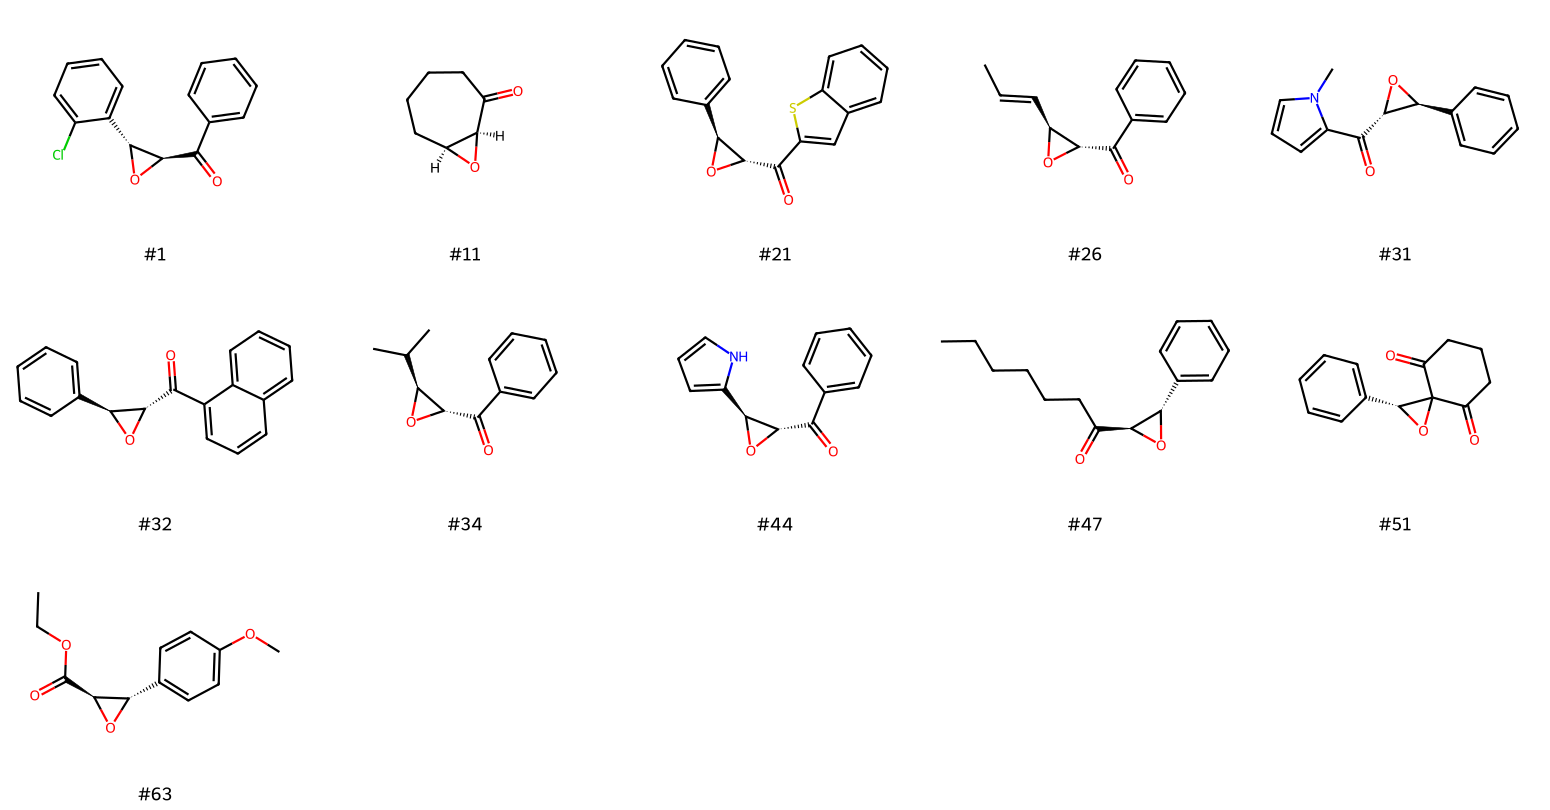

In [7]:
test_molgrid_svg = draw_train_test_molgrid(
    df=test_df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=len(test_df),
    img_size=(310, 270),
)

display(test_molgrid_svg)

In [11]:
from pathlib import Path

import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

data = pd.read_excel('exp_verification.xlsx')

print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())

print("\nDataset labels:")
#display(data["dataset"].value_counts(dropna=False))

display(data.head())

Shape: (13, 4)
Columns:
['l.p', 'SMILES', 'SMILES_product', 'ee']

Dataset labels:


,l.p,SMILES,SMILES_product,ee
0,10,C=CC1=CC(/C=C/C(C2=C(C=CC=C2)Br)=O)=CC=C1,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...,92
1,11,O=C(/C=C/C1=CC=CC=C1)C2=CC=CC=C2Br,O=C(C1=CC=CC=C1Br)[C@H]2[C@H](C3=CC=CC=C3)O2,89
2,12,O=C(/C=C/C1=C(Br)C=CC=C1)C2=CC=CC=C2,O=C([C@@H]1[C@H](O1)C2=C(Br)C=CC=C2)C3=CC=CC=C3,11
3,13,O=C(/C=C/C1=CC=CC(C(OC)OC)=C1)C2=C(Br)C=CC=C2,O=C(C1=C(C=CC=C1)Br)[C@H]2[C@H](C3=CC=CC(C(OC)...,87
4,14,O=C(/C=C/C1=CC=C(OC2=CC=CC=C2)C=C1)C3=CC=C([N+...,O=C(C1=CC=C(C=C1)[N+]([O-])=O)[C@H]2[C@H](C3=C...,90


In [13]:
from pathlib import Path

import pandas as pd


EXPERIMENTAL_FILE = 'exp_verification.xlsx'

experimental_df = pd.read_excel(
    EXPERIMENTAL_FILE
).copy()

required_columns = [
    "SMILES",
]

missing_columns = [
    column
    for column in required_columns
    if column not in experimental_df.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}\n"
    f"Available columns: {experimental_df.columns.tolist()}"
)

# The Excel row order is the intended experimental-set numbering.
experimental_df = experimental_df.reset_index(drop=True)

experimental_df["Original_Index"] = (
    experimental_df.index + 1
)

experimental_df["Structure_ID"] = (
    "#"
    + experimental_df["Original_Index"].astype(str)
)

experimental_df["AD_ID"] = (
    "Exp #"
    + experimental_df["Original_Index"].astype(str)
)

experimental_df["Dataset_label"] = (
    "Experimental verification set"
)

assert len(experimental_df) == 36, (
    f"Expected 10 experimental examples, found {len(experimental_df)}."
)

display(
    experimental_df[
        [
            "Structure_ID",
            "AD_ID",
            "Original_Index",
            "Dataset_label",
            "SMILES",
        ]
    ]
)

,Structure_ID,AD_ID,Original_Index,Dataset_label,SMILES
0,#1,Exp #1,1,Experimental verification set,C=CC1=CC([C@@H]2O[C@H]2C(C3=C(Br)C=CC=C3)=O)=C...
1,#2,Exp #2,2,Experimental verification set,O=C(C1=CC=CC=C1Br)[C@H]2[C@H](C3=CC=CC=C3)O2
2,#3,Exp #3,3,Experimental verification set,O=C([C@@H]1[C@H](O1)C2=C(Br)C=CC=C2)C3=CC=CC=C3
3,#4,Exp #4,4,Experimental verification set,O=C(C1=C(C=CC=C1)Br)[C@H]2[C@H](C3=CC=CC(C(OC)...
4,#5,Exp #5,5,Experimental verification set,O=C(C1=CC=C(C=C1)[N+]([O-])=O)[C@H]2[C@H](C3=C...
5,#6,Exp #6,6,Experimental verification set,O=C(C1=CC=C(C=C1)[N+]([O-])=O)[C@H]2[C@H](C3=C...
6,#7,Exp #7,7,Experimental verification set,O=C([C@H]1[C@H](C2=CC=C(C=C2)Br)O1)C3=CC=C(C=C3)C
7,#8,Exp #8,8,Experimental verification set,O=C(C1=CC=CC=C1)[C@H]2[C@H](C3=CC=CC=C3C(F)(F)...
8,#9,Exp #9,9,Experimental verification set,BrC1=CC=CC([C@@H]2O[C@H]2C(C3=C(C(OC)=O)C=CC=C...
9,#10,Exp #10,10,Experimental verification set,O=C([C@@H]1O[C@H]1C2=CC=C(C=C2)C)C3=CC=CC([N+]...


In [14]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D


def draw_experimental_molgrid(
    df,
    smi="SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=4,
    max_mols=200,
    img_size=(350, 300),
):
    molecules = []
    legends = []

    for dataframe_index, row in df.head(max_mols).iterrows():
        smi_ = str(row[smi])


        molecule = Chem.MolFromSmiles(smi_)

        if molecule is None:
            print(
                f"SMILES conversion error: "
                f"{row[id_col]} (row {dataframe_index})"
            )
            continue

        molecules.append(molecule)

        legends.append(
            f"{row[id_col]}\n"
            #f"{row[dataset_label_col]}"
        )

    if not molecules:
        raise ValueError(
            "No valid molecules were generated."
        )

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.035
    draw_options.bondLineWidth = 2.2

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

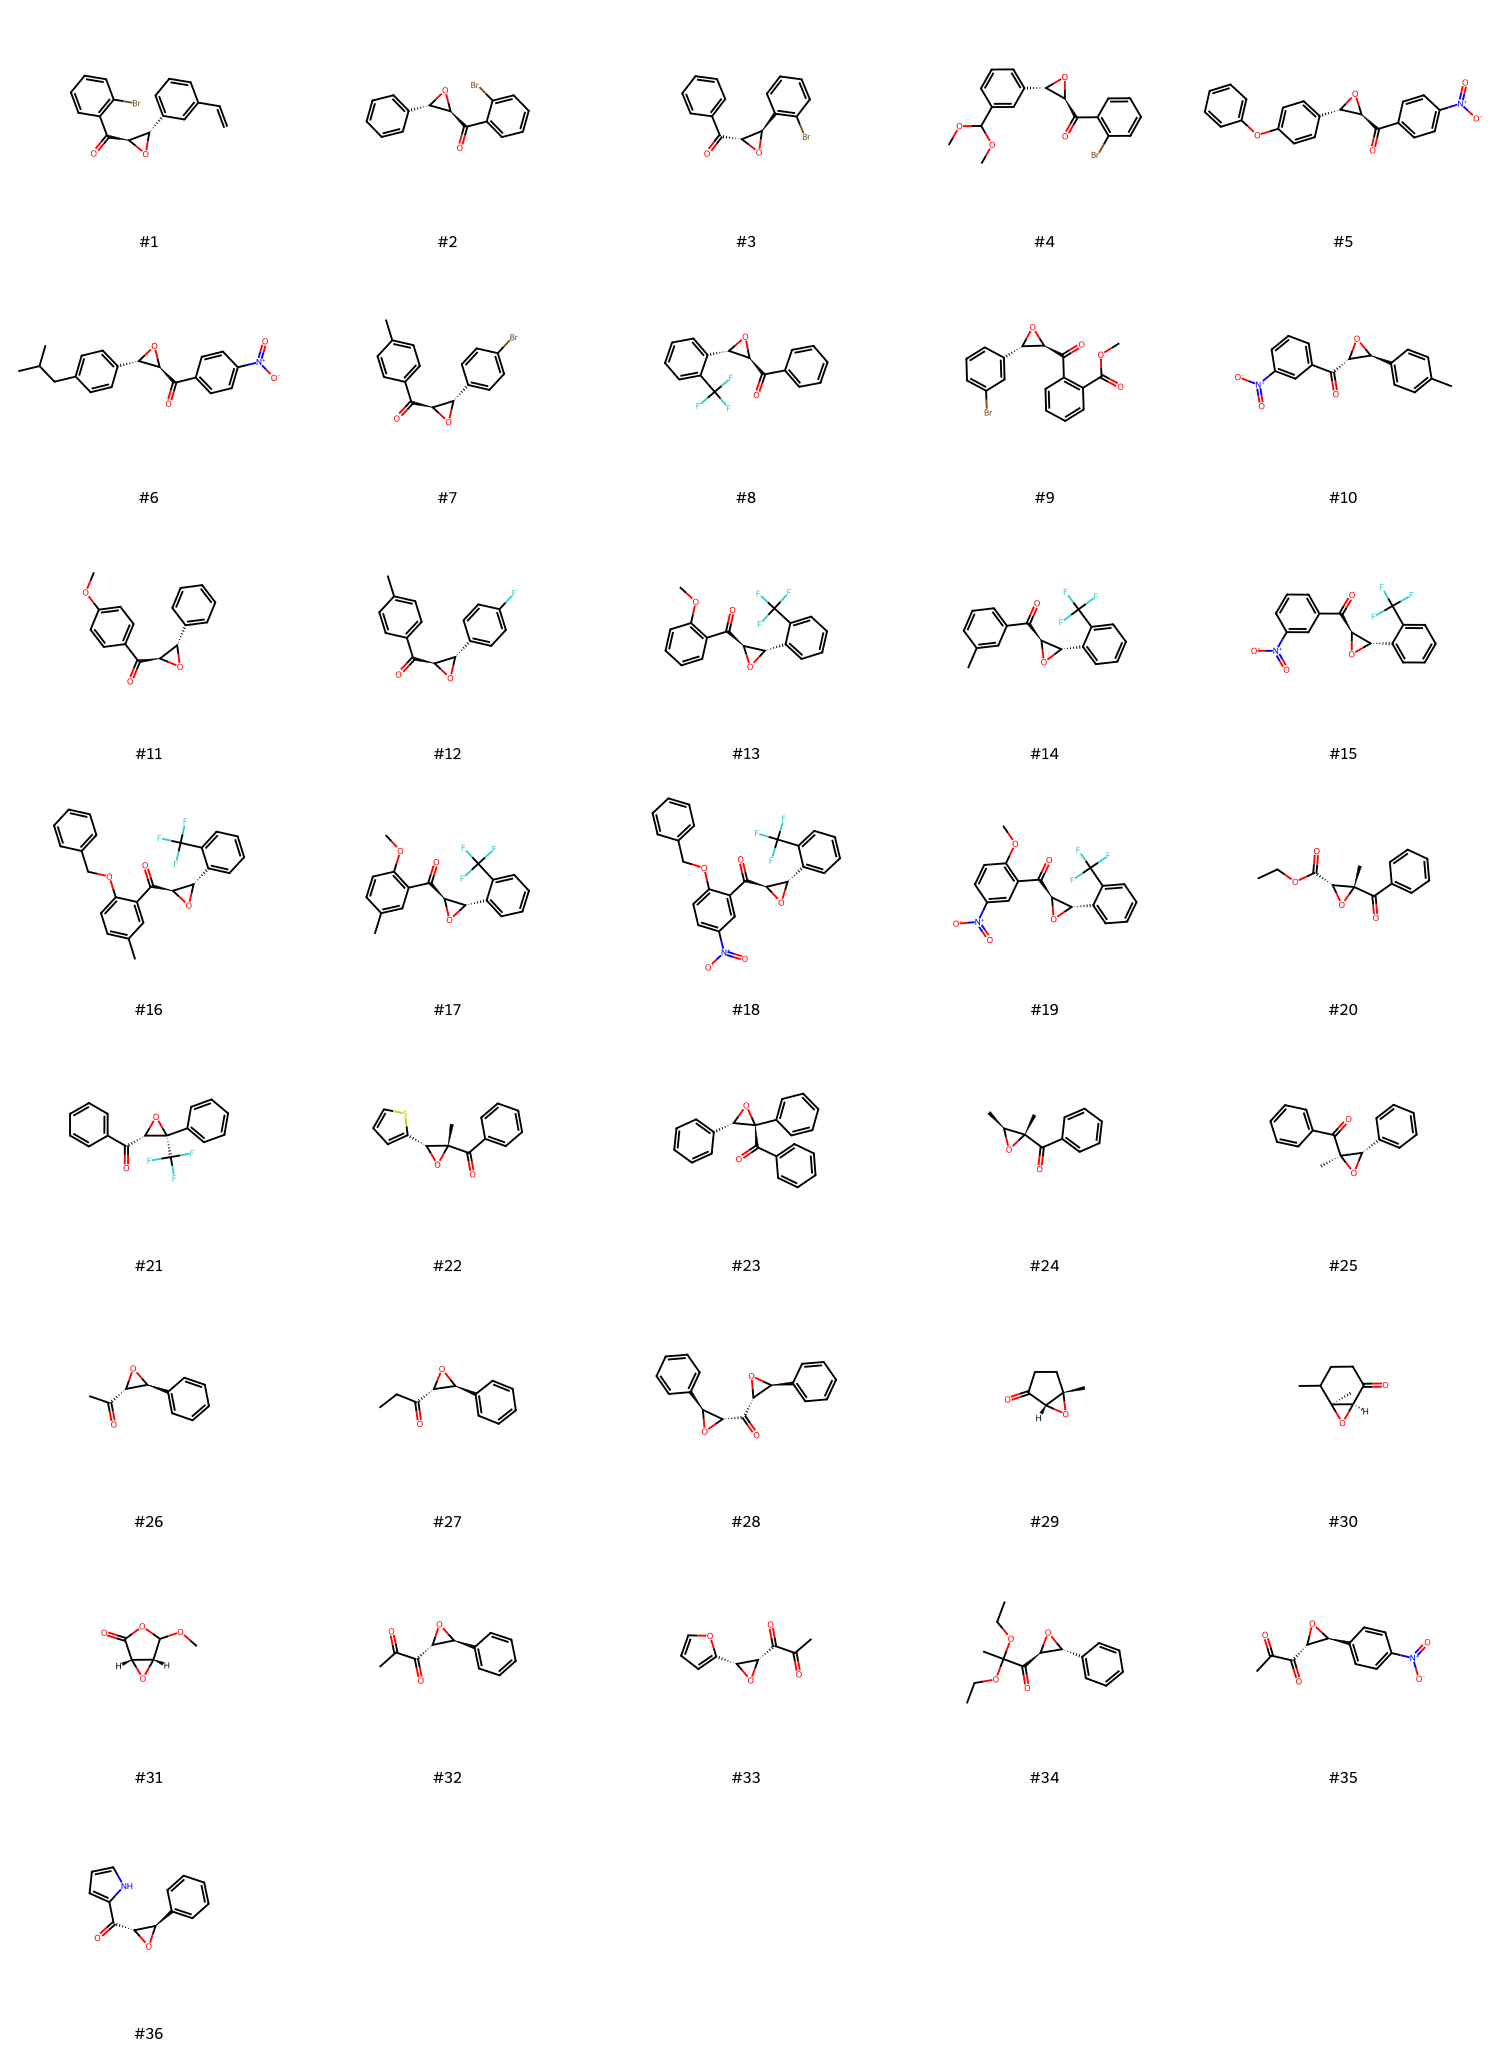

In [15]:
experimental_molgrid_svg = draw_experimental_molgrid(
    df=experimental_df,
    smi="SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=len(experimental_df),
    img_size=(350, 300),
)

display(experimental_molgrid_svg)

In [9]:
from pathlib import Path

import pandas as pd


EXPERIMENTAL_FILE = 'model_cla_val.xlsx'

experimental_df = pd.read_excel(
    EXPERIMENTAL_FILE
).copy()

required_columns = [
    "SMILES",
]

missing_columns = [
    column
    for column in required_columns
    if column not in experimental_df.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}\n"
    f"Available columns: {experimental_df.columns.tolist()}"
)

# The Excel row order is the intended experimental-set numbering.
experimental_df = experimental_df.reset_index(drop=True)

experimental_df["Original_Index"] = (
    experimental_df.index + 1
)

experimental_df["Structure_ID"] = (
    "#"
    + experimental_df["Original_Index"].astype(str)
)

experimental_df["AD_ID"] = (
    "Exp #"
    + experimental_df["Original_Index"].astype(str)
)

experimental_df["Dataset_label"] = (
    "Experimental verification set"
)

assert len(experimental_df) == 9, (
    f"Expected 10 experimental examples, found {len(experimental_df)}."
)

display(
    experimental_df[
        [
            "Structure_ID",
            "AD_ID",
            "Original_Index",
            "Dataset_label",
            "SMILES",
        ]
    ]
)

,Structure_ID,AD_ID,Original_Index,Dataset_label,SMILES
0,#1,Exp #1,1,Experimental verification set,ClC3=CC=C(C([C@@H]4O[C@H]4C5=CC=CC=C5)=O)C=C3
1,#2,Exp #2,2,Experimental verification set,O=C2CCC[C@@H]3O[C@H]23
2,#3,Exp #3,3,Experimental verification set,ClC3=CC=CC=C3C([C@@H]4O[C@H]4C5=CC=CC=C5)=O
3,#4,Exp #4,4,Experimental verification set,O=C(C4=CC=CC=C4)[C@@H]5O[C@H]5C6=CC7=CC=CC=C7O6
4,#5,Exp #5,5,Experimental verification set,CCCC[C@@H]2O[C@H]2C(C3=CC=CC=C3)=O
5,#6,Exp #6,6,Experimental verification set,O=C(C4=C(C=CC=C4)CC5)[C@@]65[C@H](/C=C/C7=CC=C...
6,#7,Exp #7,7,Experimental verification set,O=C([C@H]2[C@@H](O2)C3=CC=CC=C3)OCC
7,#8,Exp #8,8,Experimental verification set,O=C(C3=CC=C([N+]([O-])=O)C=C3)[C@@H]4O[C@H]4C5...
8,#9,Exp #9,9,Experimental verification set,FC3=CC=C([C@@H]4O[C@H]4C(C5=CC=C(C=C5)F)=O)C=C3


In [10]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D


def draw_experimental_molgrid(
    df,
    smi="SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=4,
    max_mols=200,
    img_size=(350, 300),
):
    molecules = []
    legends = []

    for dataframe_index, row in df.head(max_mols).iterrows():
        smi_ = str(row[smi])


        molecule = Chem.MolFromSmiles(smi_)

        if molecule is None:
            print(
                f"SMILES conversion error: "
                f"{row[id_col]} (row {dataframe_index})"
            )
            continue

        molecules.append(molecule)

        legends.append(
            f"{row[id_col]}\n"
            #f"{row[dataset_label_col]}"
        )

    if not molecules:
        raise ValueError(
            "No valid molecules were generated."
        )

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.035
    draw_options.bondLineWidth = 2.2

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

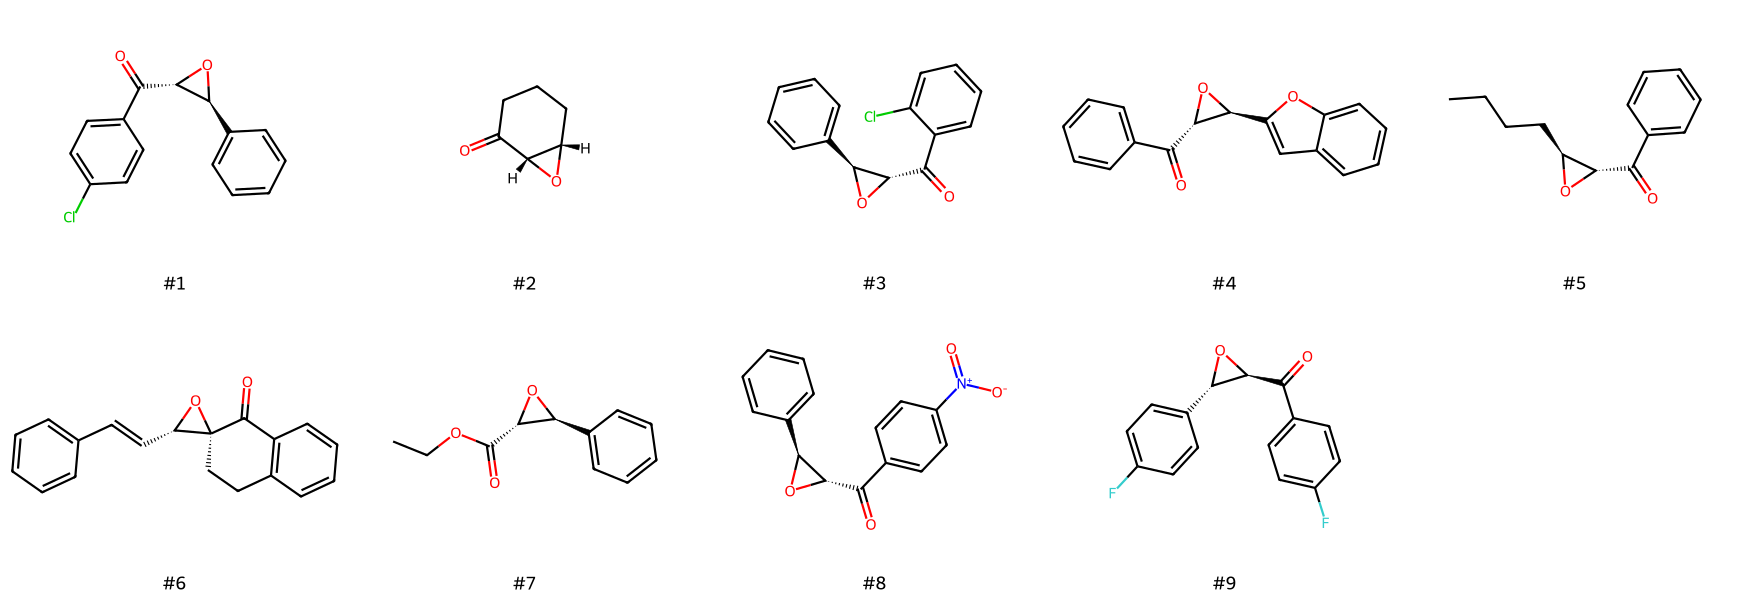

In [11]:
experimental_molgrid_svg = draw_experimental_molgrid(
    df=experimental_df,
    smi="SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=len(experimental_df),
    img_size=(350, 300),
)

display(experimental_molgrid_svg)